Import Libraries

In [1]:
!pip install numpy pandas scikit-learn nltk spacy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [37]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
import re

In [79]:
# import libraries for model training
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, confusion_matrix, classification_report

In [47]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('/content/SMSSpamCollection',sep="\t",header=None, names=['label','messages'])

In [6]:
print(df.head())

  label                                           messages
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [7]:
print("Shape of dataset\n")
print(df.shape)

Shape of dataset

(5572, 2)


In [8]:
print("Column of Dataset \n")
print(df.columns)

Column of Dataset 

Index(['label', 'messages'], dtype='object')


In [9]:
print("Information \n")
print(df.info())

Information 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     5572 non-null   object
 1   messages  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [10]:
print("Data types \n")
print(df.dtypes)

Data types 

label       object
messages    object
dtype: object


In [11]:
print("Random Samples \n")
print(df.sample(5))

Random Samples 

     label                                           messages
3718   ham                       I'm gonna rip out my uterus.
645    ham  Allo! We have braved the buses and taken on th...
5395   ham  Dunno lei shd b driving lor cos i go sch 1 hr ...
2994   ham                     So i'm doing a list of buyers.
111    ham           What is the plural of the noun research?


In [12]:
print("\n Summary")
print(df.describe(include=[object]))


 Summary
       label                messages
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


Explarotay Data Analysis

In [13]:
df.isnull().sum()

,0
label,0
messages,0


In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df[df.duplicated()].sum()

,0
label,hamhamhamhamhamhamspamhamhamhamhamhamhamhamham...
messages,As per your request 'Melle Melle (Oru Minnamin...


In [16]:
#Removing duplicated rows
df=df.drop_duplicates(keep='first')

In [17]:
#Now again checking the duplicated rows
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(5169, 2)

Check Class Distribution

In [19]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


Plot Class Distribution (Count Plot)

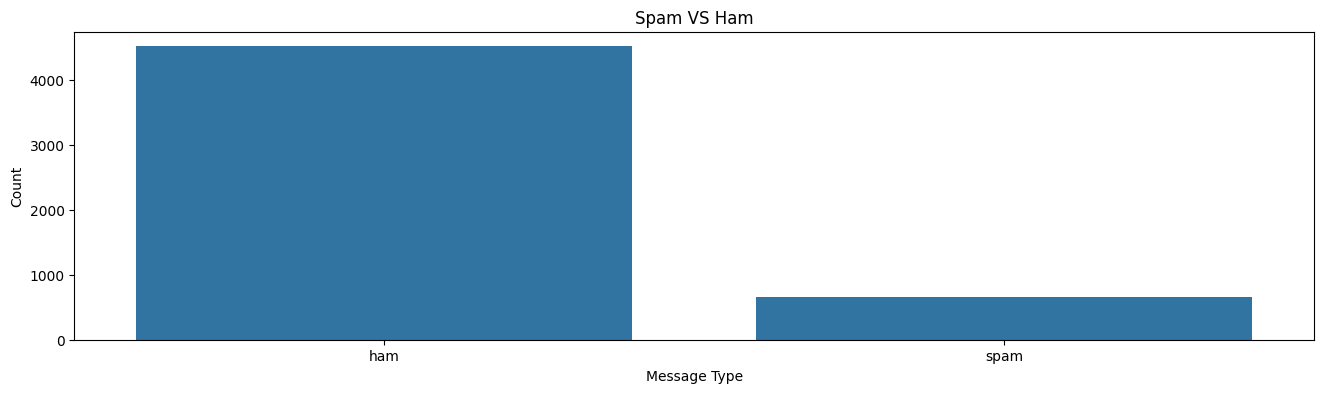

In [20]:
plt.figure(figsize=(16,4))
sns.countplot(x="label",data=df)
plt.title("Spam VS Ham")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()


Pie Chart

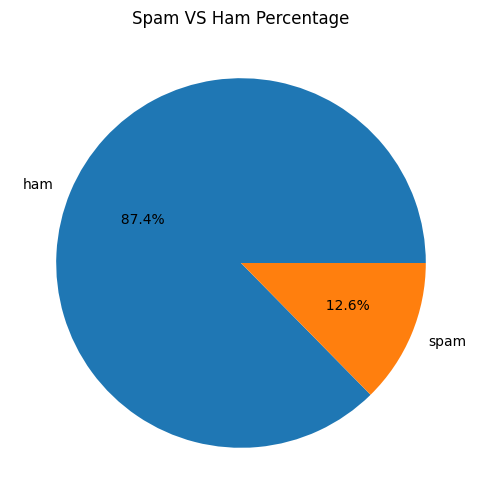

In [25]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%6.1f%%",
    figsize=(6,6)
)
plt.title("Spam VS Ham Percentage")
plt.ylabel("")
plt.show()

Message Length Analysis

In [27]:
df["message_length"] = df["messages"].apply(len)
df.head()

,label,messages,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


Statistics of Message Length

In [28]:
df["message_length"].describe()

,message_length
count,5169.000000
mean,79.344554
std,58.437457
min,2.000000
25%,36.000000
50%,61.000000
75%,119.000000
max,910.000000


Histogram of Message length

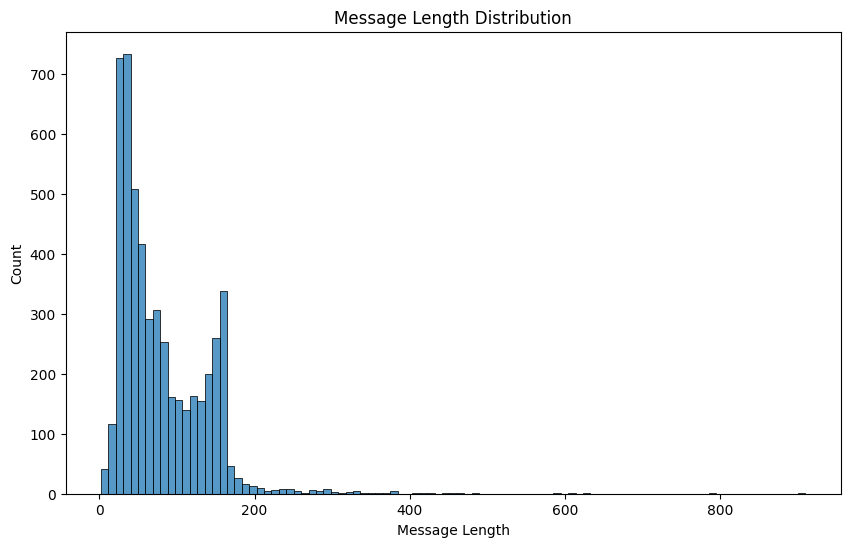

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(df["message_length"])
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.show()


Compare Spam vs Ham Length

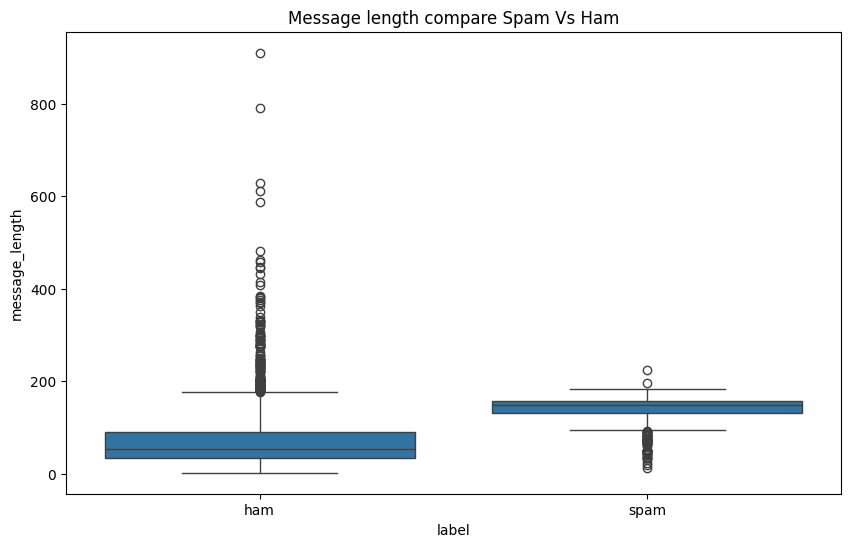

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(x="label",y="message_length",data=df)
plt.title("Message length compare Spam Vs Ham")
plt.show()

Average Length

In [32]:
df.groupby("label")["message_length"].mean()

,message_length
label,
ham,70.905890
spam,137.704441


longest Message

In [33]:
df.loc[df["message_length"].idxmax()]

,1085
label,ham
messages,For me the love should start with attraction.i...
message_length,910


Shortest Message

In [34]:
df.loc[df["message_length"].idxmin()]

,1925
label,ham
messages,Ok
message_length,2


Text preprocessing

In [39]:
df["messages"] = df["messages"].str.lower()

In [40]:
df["messages"].head()

,messages
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."


Tokenization

In [48]:
text = df["messages"][0]
tokens = word_tokenize(text)
print(tokens)

['go', 'until', 'jurong', 'point', ',', 'crazy', '..', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', '...', 'cine', 'there', 'got', 'amore', 'wat', '...']


Remove Punctuation

In [51]:
text = df["messages"]
text = "".join(char for char in text if char not in string.punctuation )
print(text)

go un


Remove Numbers

In [55]:
text = df["messages"]
text = "".join(char for char in text if not char.isdigit())
print(text)

go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...ok lar... joking wif u oni...free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18'su dun say so early hor... u c already then say...nah i don't think he goes to usf, he lives around here thoughfreemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send, £1.50 to rcveven my brother is not like to speak with me. they treat me like aids patent.as per your request 'melle melle (oru minnaminunginte nurungu vettam)' has been set as your callertune for all callers. press *9 to copy your friends callertunewinner!! as a valued network customer you have been selected to receivea £900 prize reward! to claim call 09061701461. claim code kl341. valid 12 hours only.had your mobile 11 months or more? u r entitled to upd

Remove Stopwords

In [56]:
stop_words = set(stopwords.words("english"))
print(stop_words)

{"won't", "wasn't", 'it', 'up', "weren't", "aren't", 'all', 'shan', 'me', 'doesn', 'there', 'herself', 'during', 'few', 'which', 'should', 'him', 'out', "she'll", 'yours', 'why', 'them', 'further', "hasn't", "wouldn't", 'these', 'other', "i've", 'under', 'mightn', 'so', 'itself', 'm', 'nor', "couldn't", 'y', "you've", 'most', 'themselves', 'my', 'a', 'their', 'both', 'don', "we'll", 'be', 'whom', 'over', 'didn', "mustn't", "isn't", 'himself', "mightn't", "we're", 'she', 'hadn', 'once', 'he', 'than', 'if', 'being', 'same', 'above', 'until', 'myself', 'now', 'such', 'and', 'are', "we've", 'weren', 'i', 'needn', 've', 'as', 'down', 'in', 'been', 'has', "doesn't", 'here', "she'd", 'into', 'only', 'theirs', 'won', 'yourself', "you'll", "they'll", 'mustn', 'hers', 'that', 'does', 'can', "she's", 'you', 'your', 'is', 'from', 'wouldn', 'between', 'its', 'll', 'some', 'by', 'at', 'but', 'own', 's', "i'll", 'will', 'for', 'where', 'this', "we'd", 'yourselves', 'did', 'aren', 'before', 'ourselves

In [ ]:
words = df["messages"]


In [58]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # Join words
    return " ".join(tokens)

apply on dataset

In [59]:
df["clean_message"] = df["messages"].apply(preprocess_text)

Compare Before & After

In [61]:
df[["messages", "clean_message"]].head()

,messages,clean_message
0,"go until jurong point, crazy.. available only ...",go jurong point crazi avail bugi n great world...
1,ok lar... joking wif u oni...,ok lar joke wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...,free entri wkli comp win fa cup final tkt st m...
3,u dun say so early hor... u c already then say...,u dun say earli hor u c alreadi say
4,"nah i don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


Count Vectorizer

In [72]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
# Convert text into numerical features
X = cv.fit_transform(df["clean_message"])
# Label
Y = df["label"]
# check shape
print("Feature Matrix Shape:",X.shape)
print("Target Vector Shape:",Y.shape)

print(cv.get_feature_names_out()[:20])


Feature Matrix Shape: (5169, 7156)
Target Vector Shape: (5169,)
['aa' 'aah' 'aaniy' 'aaooooright' 'aathilov' 'aathiwher' 'ab' 'abbey'
 'abdomen' 'abeg' 'abelu' 'aberdeen' 'abi' 'abil' 'abiola' 'abj' 'abl'
 'abnorm' 'abouta' 'abroad']


TFIDF

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf =  TfidfVectorizer()
# convert text into vectors
X = tf.fit_transform(df["clean_message"])
# Target variable
Y=df["label"]
# check shape
print("Feature Matrix Shape:",X.shape)
print("Target Vector Shape:",Y.shape)
print(tf.get_feature_names_out()[:20])

Feature Matrix Shape: (5169, 7156)
Target Vector Shape: (5169,)
['aa' 'aah' 'aaniy' 'aaooooright' 'aathilov' 'aathiwher' 'ab' 'abbey'
 'abdomen' 'abeg' 'abelu' 'aberdeen' 'abi' 'abil' 'abiola' 'abj' 'abl'
 'abnorm' 'abouta' 'abroad']


Training and SPlitting

In [80]:
# encoding labels before model training
y = df["label"].map({
    "ham":0,
    "spam":1
})

In [94]:
X_train, X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [95]:
print("Training Samples",X_train.shape[0])
print("Testing Samples",X_test.shape[0])

Training Samples 4135
Testing Samples 1034


In [96]:
model = MultinomialNB()
model.fit(X_train,y_train)


MultinomialNB()

In [97]:
y_pred = model.predict(X_test)

In [98]:
# accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9661508704061895


In [99]:
precision = precision_score(y_test, y_pred)
print("Precision :",precision)

Precision : 0.9897959183673469


In [100]:
# recall
recall = recall_score(y_test, y_pred)
print("Recall :", recall)

Recall : 0.7404580152671756


In [102]:
f1 = f1_score(y_test, y_pred)
print("F1 Score :", f1)

F1 Score : 0.8471615720524017


In [104]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[902   1]
 [ 34  97]]


In [106]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



Heatplot

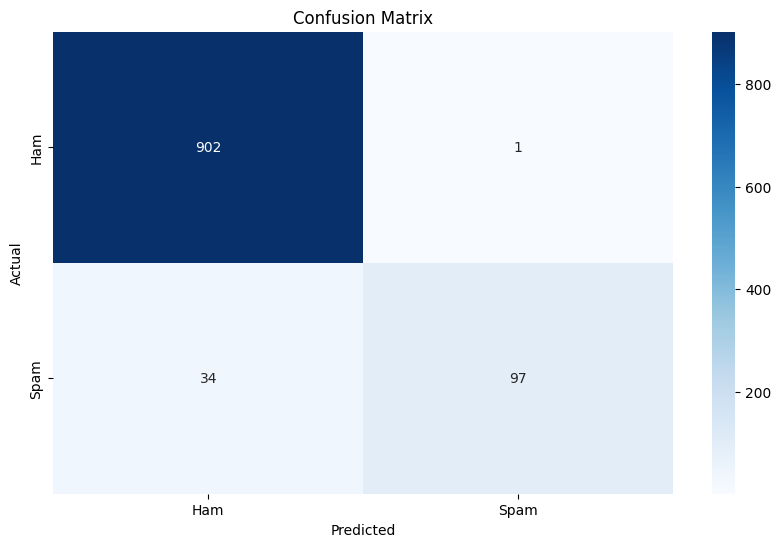

In [108]:
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=["Ham","Spam"],yticklabels=["Ham","Spam"] )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [114]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
y_prob = model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
print("AUC Score:", roc)


AUC Score: 0.9801256202818425


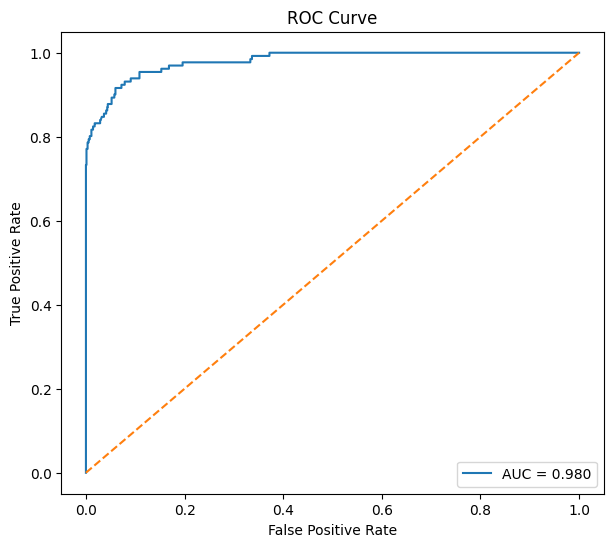

In [115]:
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

Cross Validation

In [116]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cross validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)
print("\nMean Accuracy:")
print(scores.mean())
print("\nStandard Deviation:")
print(scores.std())

Cross Validation Scores:
[0.96324952 0.9622824  0.95261122 0.95841393 0.96127783]

Mean Accuracy:
0.9595669783039764

Standard Deviation:
0.0038359805665120184


In [119]:
from sklearn.model_selection import GridSearchCV
param_grid = { "alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0] }
grid = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid.fit(X, y)
print("Best Parameters:", grid.best_params_)
print("Best Score",grid.best_score_)


Best Parameters: {'alpha': 0.1}
Best Score 0.8982672689651523


In [121]:
best_model = grid.best_estimator_

In [122]:
y_pred = best_model.predict(X_test)

In [123]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9961315280464217
Precision: 0.9922480620155039
Recall : 0.9770992366412213
F1 Score : 0.9846153846153847


Saving the Model

In [124]:
pip install joblib

In [125]:
import joblib
joblib.dump(best_model, "spam_detector.pkl")

['spam_detector.pkl']

In [128]:
joblib.dump(tf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']